In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import pickle as pkl
from scipy.stats import mannwhitneyu
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('ggplot')


feature_path= '/space/gzanardini/tuh_features_whole/'
feature_list=[file for file in os.listdir(feature_path) if file.endswith('.npy')]
description= pd.read_csv('/space/gzanardini/tuh_features_whole/description.csv')
labels=description['epilepsy'].values

def mann_whitney_test(x, y):
    stat, p = mannwhitneyu(x, y)
    return p

# sort the feature list
feature_list.sort()

feature_names = ['cc', 'cwt', 'dwt', 'gcc', 'gplv','plv','mst','sst','spectral','utm']
# split the features based on the feature names
feature_dict = {}
for feature in feature_names:
    feature_dict[feature] = [f for f in feature_list if f.startswith(feature)]

type: cc
montage: BipolarDB
seg_length: 10.npy
features shape: (40, 765)
lowest 10 p-values:
index: 37 p-value: 0.0002451055690752662
index: 630 p-value: 0.0016464904031048908
index: 649 p-value: 0.002936736152231303
index: 190 p-value: 0.0035394820896658586
index: 636 p-value: 0.003881267066386809
index: 483 p-value: 0.004656243846620988
index: 751 p-value: 0.0066397015825656915
index: 477 p-value: 0.0085947860810667
index: 496 p-value: 0.009352614900744193
index: 427 p-value: 0.009352614900744193
type: cc
montage: BipolarDB
seg_length: 1.npy
features shape: (40, 765)
lowest 10 p-values:
index: 37 p-value: 0.00042679161905815764
index: 235 p-value: 0.0008975920348904338
index: 343 p-value: 0.005568775840425183
index: 483 p-value: 0.005568775840425183
index: 190 p-value: 0.006083042605774964
index: 617 p-value: 0.00724174506874109
index: 427 p-value: 0.00789233058956265
index: 464 p-value: 0.01016950062989578
index: 477 p-value: 0.011049311630364371
index: 636 p-value: 0.01104931163036

ValueError: num must be an integer with 1 <= num <= 16, not 17

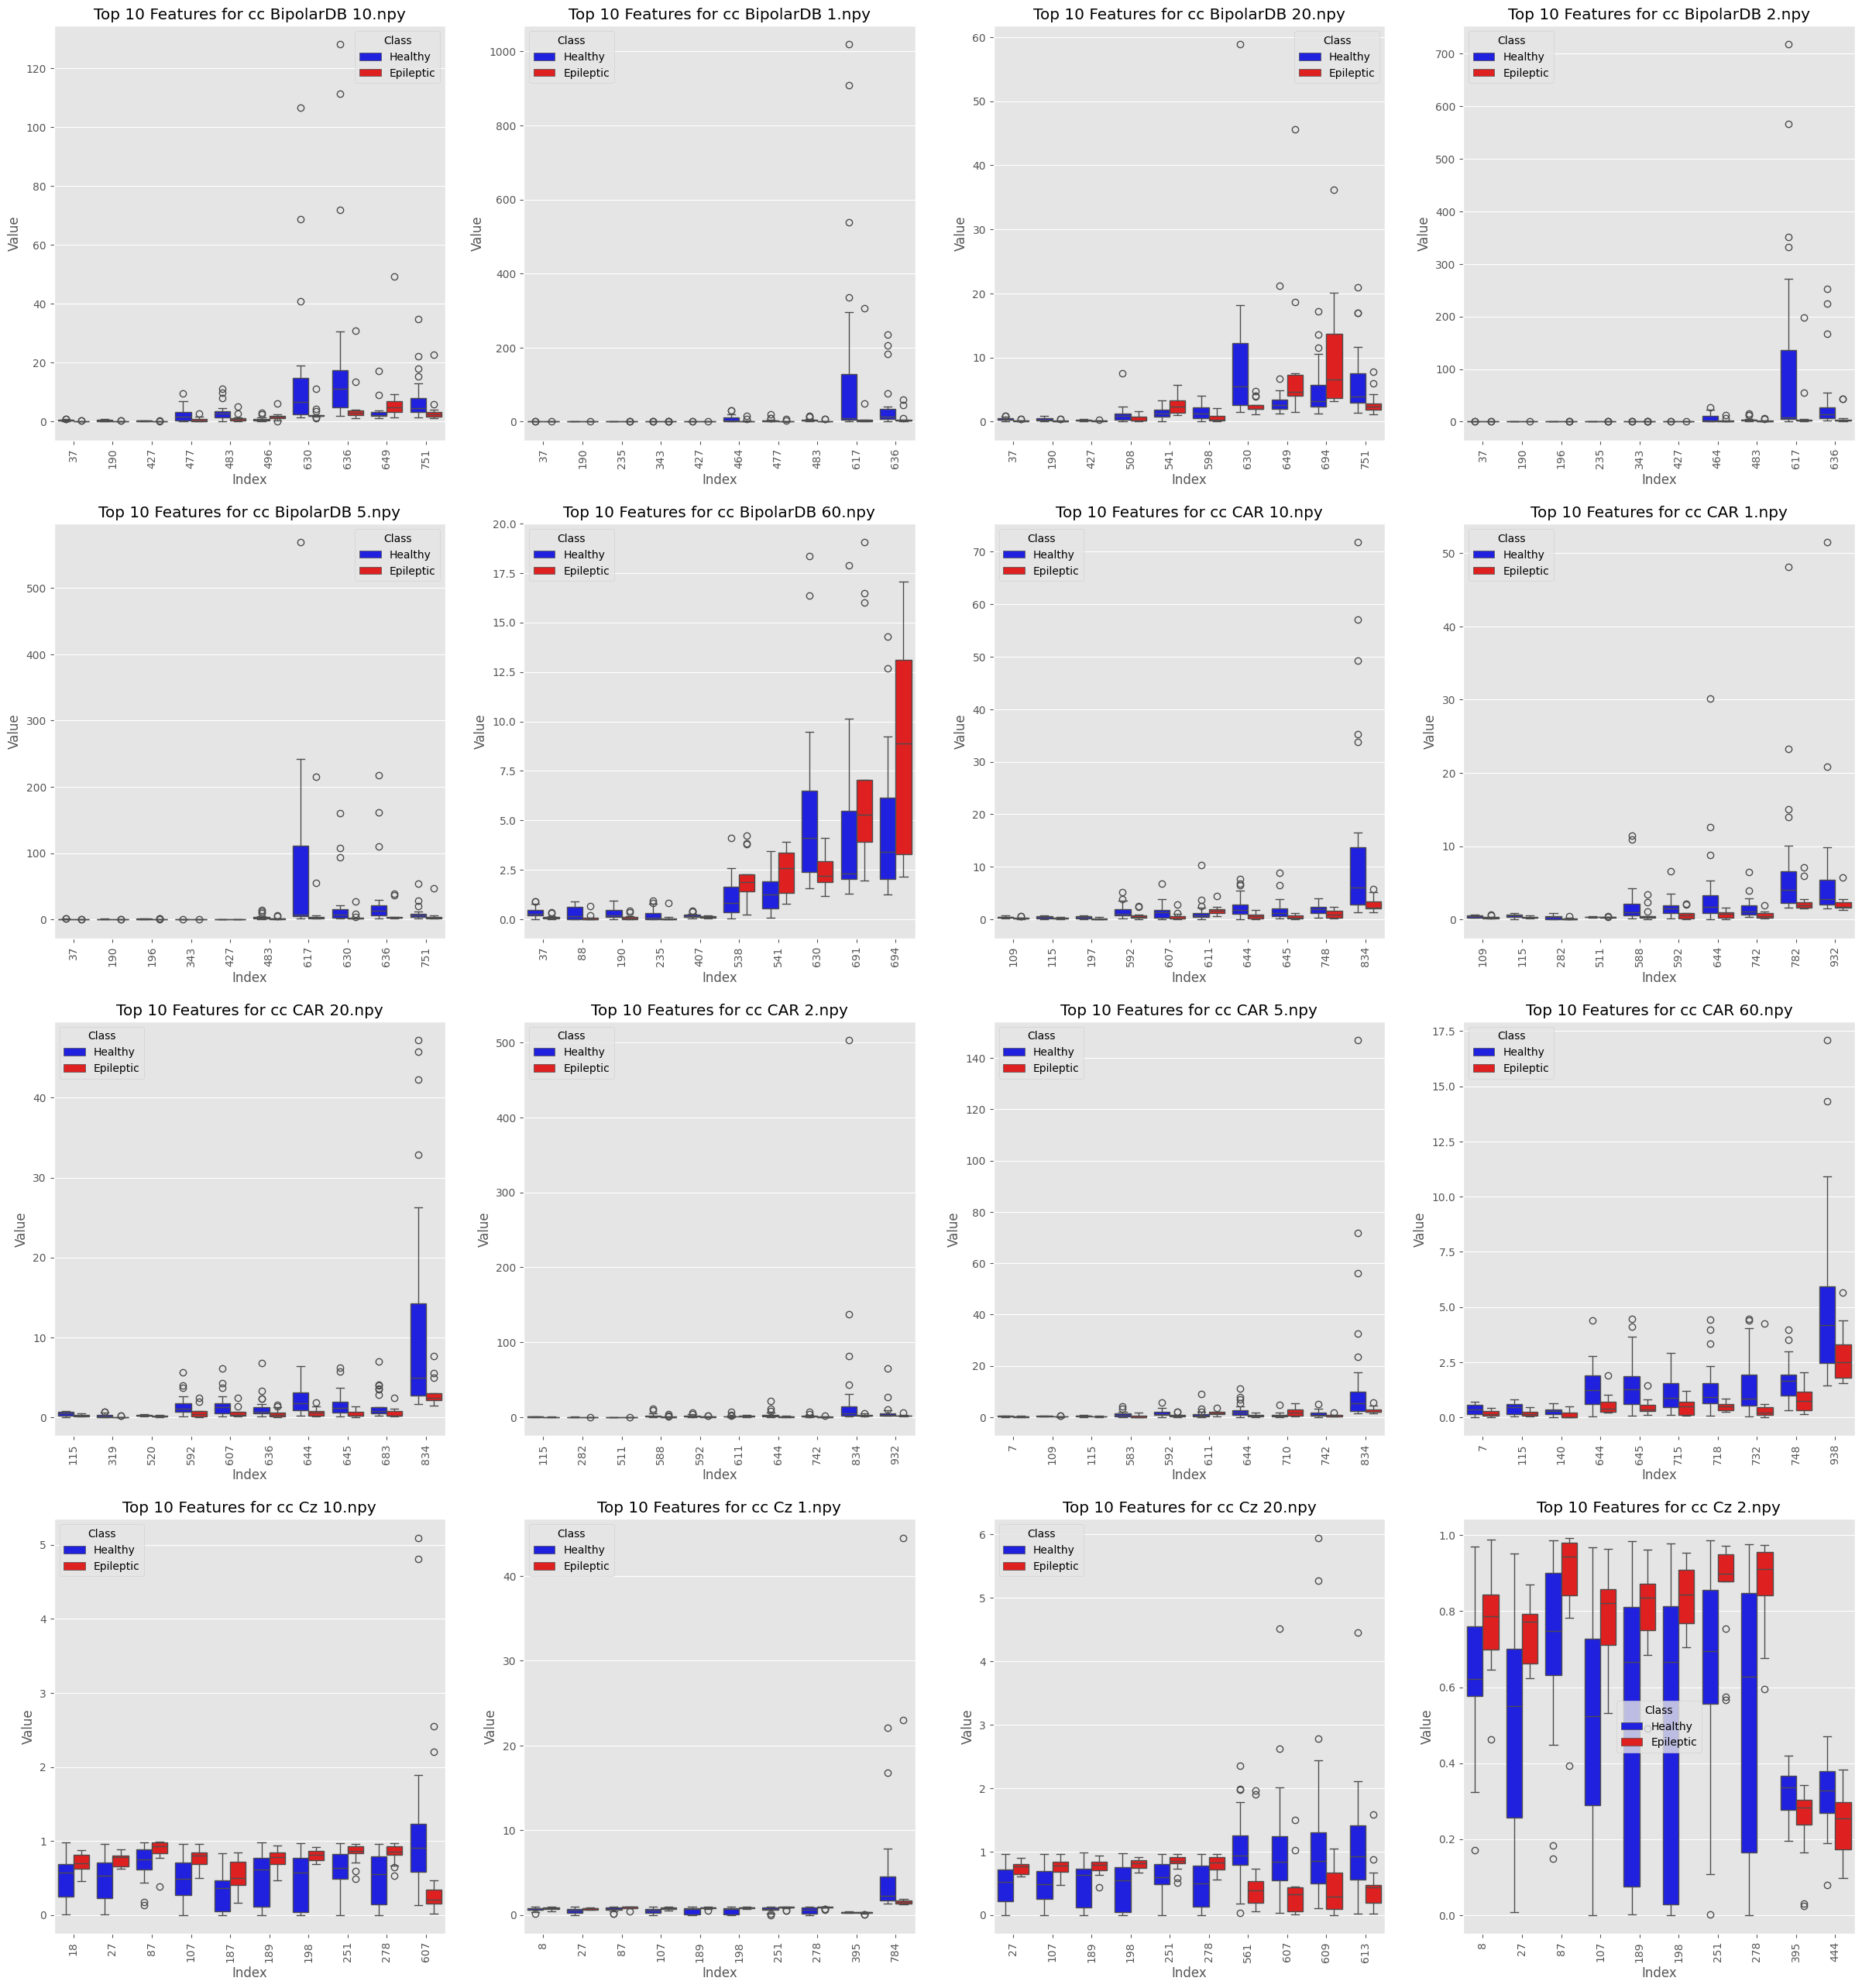

In [2]:
lowest_pval_df = pd.DataFrame(columns=["Montage", "SegLength", 'Feature Index', "LowestPValue"], index=feature_names)

for ff, feature_name in enumerate(feature_names):
    plt.figure(figsize=(30,32))
    min_pval = 1
    for pp, set in enumerate(feature_dict[feature_name]):
        features = np.abs(np.load(os.path.join(feature_path, set)))
        if len(features.shape) == 3:
            features = features.reshape(features.shape[0], features.shape[1]*features.shape[2])
        type = set.split('_')[0]
        montage = set.split('_')[1]
        seg_length = set.split('_')[2].replace('s', '')
        print('type:', type)
        print('montage:', montage)
        print('seg_length:', seg_length)
        print('features shape:', features.shape)
        ps = np.array([mann_whitney_test(features[labels==0][:,i], features[labels==1][:,i]) for i in range(features.shape[1])])
        lowest_indices = np.where(ps < 0.05)[0]
        lowest_indices_sorted = lowest_indices[np.argsort(ps[lowest_indices])]
        lowest_10 = lowest_indices_sorted[:10]
        print('lowest 10 p-values:')
        for i in lowest_10:
            print('index:', i, 'p-value:', ps[i])
        temp_data = []
        for i in lowest_10:
            for label_class in [0,1]:
                for val in features[labels==label_class][:, i]:
                    temp_data.append({"FeatureIndex": i, "Value": val, "Class": label_class})
        # Update the lowest p-value DataFrame
        if len(lowest_indices) > 0 and min(ps[lowest_indices]) < min_pval:
            min_pval = min(ps[lowest_indices])
            lowest_pval_df.loc[feature_name] = [montage, seg_length, lowest_indices_sorted[0], min_pval]
        df = pd.DataFrame(temp_data)
        if not df.empty:
            df['Class'] = df['Class'].map({0: 'Healthy', 1: 'Epileptic'})
            plt.subplot(4,4,pp+1)
            sns.boxplot(x="FeatureIndex", y="Value", hue="Class", data=df, hue_order=['Healthy','Epileptic'], palette=['blue','red'],legend='brief')
            plt.title(f"Top 10 Features for {type} {montage} {seg_length}")
            plt.xticks(rotation=90)
            plt.xlabel('Index')
            plt.ylabel('Value')
    plt.suptitle(f"Top 10 Features for {feature_name}", fontsize=20)
    plt.tight_layout()
    plt.subplots_adjust(top=0.96)
    plt.show()
# Display the DataFrame with lowest p-values
print(lowest_pval_df)
lowest_pval_df